Epoch 0, Loss: 0.34757307406748295
Epoch 1000, Loss: 0.24412841962567594
Epoch 2000, Loss: 0.22233680831482877
Epoch 3000, Loss: 0.18741485043995798
Epoch 4000, Loss: 0.13874654378756776
Epoch 5000, Loss: 0.09137639351912231
Epoch 6000, Loss: 0.05827133984966569
Epoch 7000, Loss: 0.038729048154856775
Epoch 8000, Loss: 0.027396555789519512
Epoch 9000, Loss: 0.020508152605089872
Predicciones XOR:
[[0.]
 [1.]
 [1.]
 [0.]]


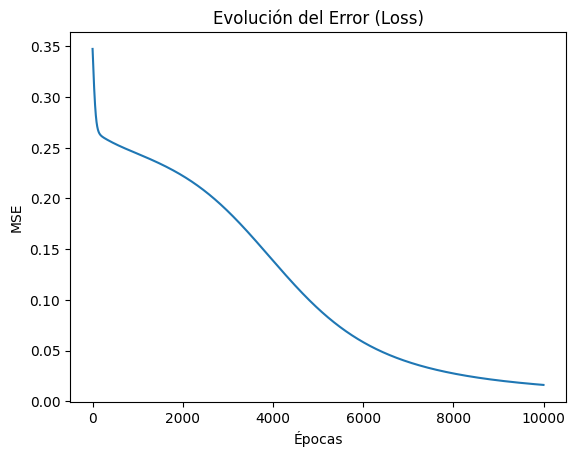

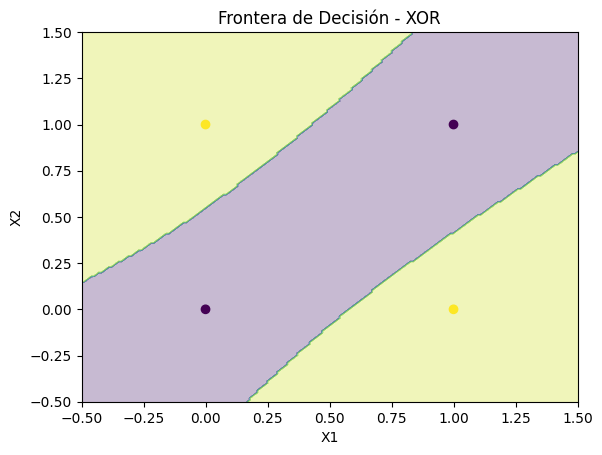

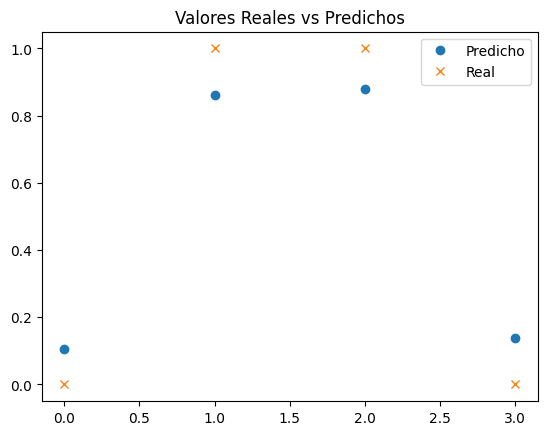

In [24]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1 - a)

class MLP:

    def __init__(self, layers, learning_rate=0.1, epochs=10000):
        self.layers = layers
        self.learning_rate = learning_rate
        self.epochs = epochs

        self.weights = []
        self.biases = []
        self.loss_history = []   # 🔥 Guardar evolución del error

        # Inicialización dinámica
        for i in range(len(layers)-1):
            self.weights.append(np.random.randn(layers[i], layers[i+1]))
            self.biases.append(np.zeros((1, layers[i+1])))


    def forward(self, X):

        self.activations = [X]

        for i in range(len(self.weights)):
            z = np.dot(self.activations[-1], self.weights[i]) + self.biases[i]
            a = sigmoid(z)
            self.activations.append(a)

        return self.activations[-1]


    def backward(self, X, y):

        m = X.shape[0]
        deltas = []

        # Error salida
        error = self.activations[-1] - y
        delta = error * sigmoid_derivative(self.activations[-1])
        deltas.append(delta)

        # Propagación hacia atrás
        for i in reversed(range(len(self.weights)-1)):
            error = np.dot(deltas[-1], self.weights[i+1].T)
            delta = error * sigmoid_derivative(self.activations[i+1])
            deltas.append(delta)

        deltas.reverse()

        # Actualización
        for i in range(len(self.weights)):
            self.weights[i] -= self.learning_rate * np.dot(self.activations[i].T, deltas[i]) / m
            self.biases[i] -= self.learning_rate * np.sum(deltas[i], axis=0, keepdims=True) / m


    def fit(self, X, y):

        for epoch in range(self.epochs):
            output = self.forward(X)
            self.backward(X, y)

            loss = np.mean((y - output) ** 2)
            self.loss_history.append(loss)

            if epoch % 1000 == 0:
                print(f"Epoch {epoch}, Loss: {loss}")


    def predict(self, X):
        output = self.forward(X)
        return np.round(output)


# -------------------------
# DATOS XOR
# -------------------------

X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])

y = np.array([[0],
              [1],
              [1],
              [0]])

modelo = MLP(
    layers=[2, 8, 1],
    learning_rate=0.1,
    epochs=10000
)

modelo.fit(X, y)

print("Predicciones XOR:")
print(modelo.predict(X))


# ===============================
# 🔵 1. GRÁFICA DE ERROR
# ===============================

plt.figure()
plt.plot(modelo.loss_history)
plt.title("Evolución del Error (Loss)")
plt.xlabel("Épocas")
plt.ylabel("MSE")
plt.show()


# ===============================
# 🔵 2. FRONTERA DE DECISIÓN
# ===============================

x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

grid = np.c_[xx.ravel(), yy.ravel()]
Z = modelo.predict(grid)
Z = Z.reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:,0], X[:,1], c=y.flatten())
plt.title("Frontera de Decisión - XOR")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()


# ===============================
# 🔵 3. REAL VS PREDICHO
# ===============================

predicciones = modelo.forward(X)

plt.figure()
plt.plot(predicciones, 'o', label="Predicho")
plt.plot(y, 'x', label="Real")
plt.legend()
plt.title("Valores Reales vs Predichos")
plt.show()